**Title**

Breast Cancer Detection System using Random Forest Classifier

**Objective**

To develop a machine learning system that predicts whether a breast tumor is:
*   Benign (non-cancerous)
*   Malignant (cancerous)

using patient diagnostic features and a Random Forest classification algorithm.

**Breast Cancer Prediction System
Dataset Information**

The dataset used in this project is

the **Wisconsin Breast Cancer Dataset**

This dataset is widely used for machine learning classification tasks in the medical domain. The objective is to predict whether a tumor is malignant or benign based on various medical measurements obtained from digitized images of breast mass cell nuclei.

**Target Variable (y)**

Diagnosis
Value	Meaning

* M	Malignant (Cancerous)

* B	Benign (Non-Cancerous)



The model predicts whether the tumor belongs to the malignant or benign category.

Input Features (X)

The dataset contains several numerical features computed from breast cell nuclei images.

Ten Main Characteristics
1. Radius

Mean of distances from the center to points on the perimeter.

2. Texture

Standard deviation of gray-scale values.

3. Perimeter

Length of the boundary around the tumor.

4. Area

Area occupied by the tumor cells.

5. Smoothness

Local variation in radius lengths.

6. Compactness

Calculated as:

(perimeter² / area) − 1.0

Measures how compact the tumor shape is.

7. Concavity

Severity of concave portions of the contour.

8. Concave Points

Number of concave portions present in the contour.

9. Symmetry

Measures symmetry of the cell nuclei shape.

10. Fractal Dimension

Coastline approximation used to measure boundary complexity.

In [ ]:
# ============================================
# Breast Cancer Detection System
# Using Random Forest Classifier
# ============================================

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [2]:
# ============================================
# Step 2: Load Dataset
# ============================================

data = pd.read_csv("data.csv")

print("First 5 Rows:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)

print("\nDataset Info:")
print(data.info())

First 5 Rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wor

In [3]:
# ============================================
# Step 3: Data Cleaning
# ============================================

# Drop unnecessary columns
data.drop(columns=["id", "Unnamed: 32"], inplace=True)

# Convert diagnosis column
# M = Malignant -> 1
# B = Benign -> 0

encoder = LabelEncoder()
data["diagnosis"] = encoder.fit_transform(data["diagnosis"])

print("\nUpdated Dataset:")
print(data.head())



Updated Dataset:
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...      

In [4]:
# ============================================
# Step 4: Check Missing Values
# ============================================

print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


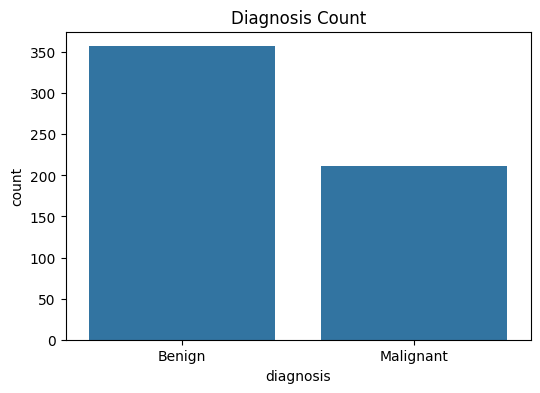

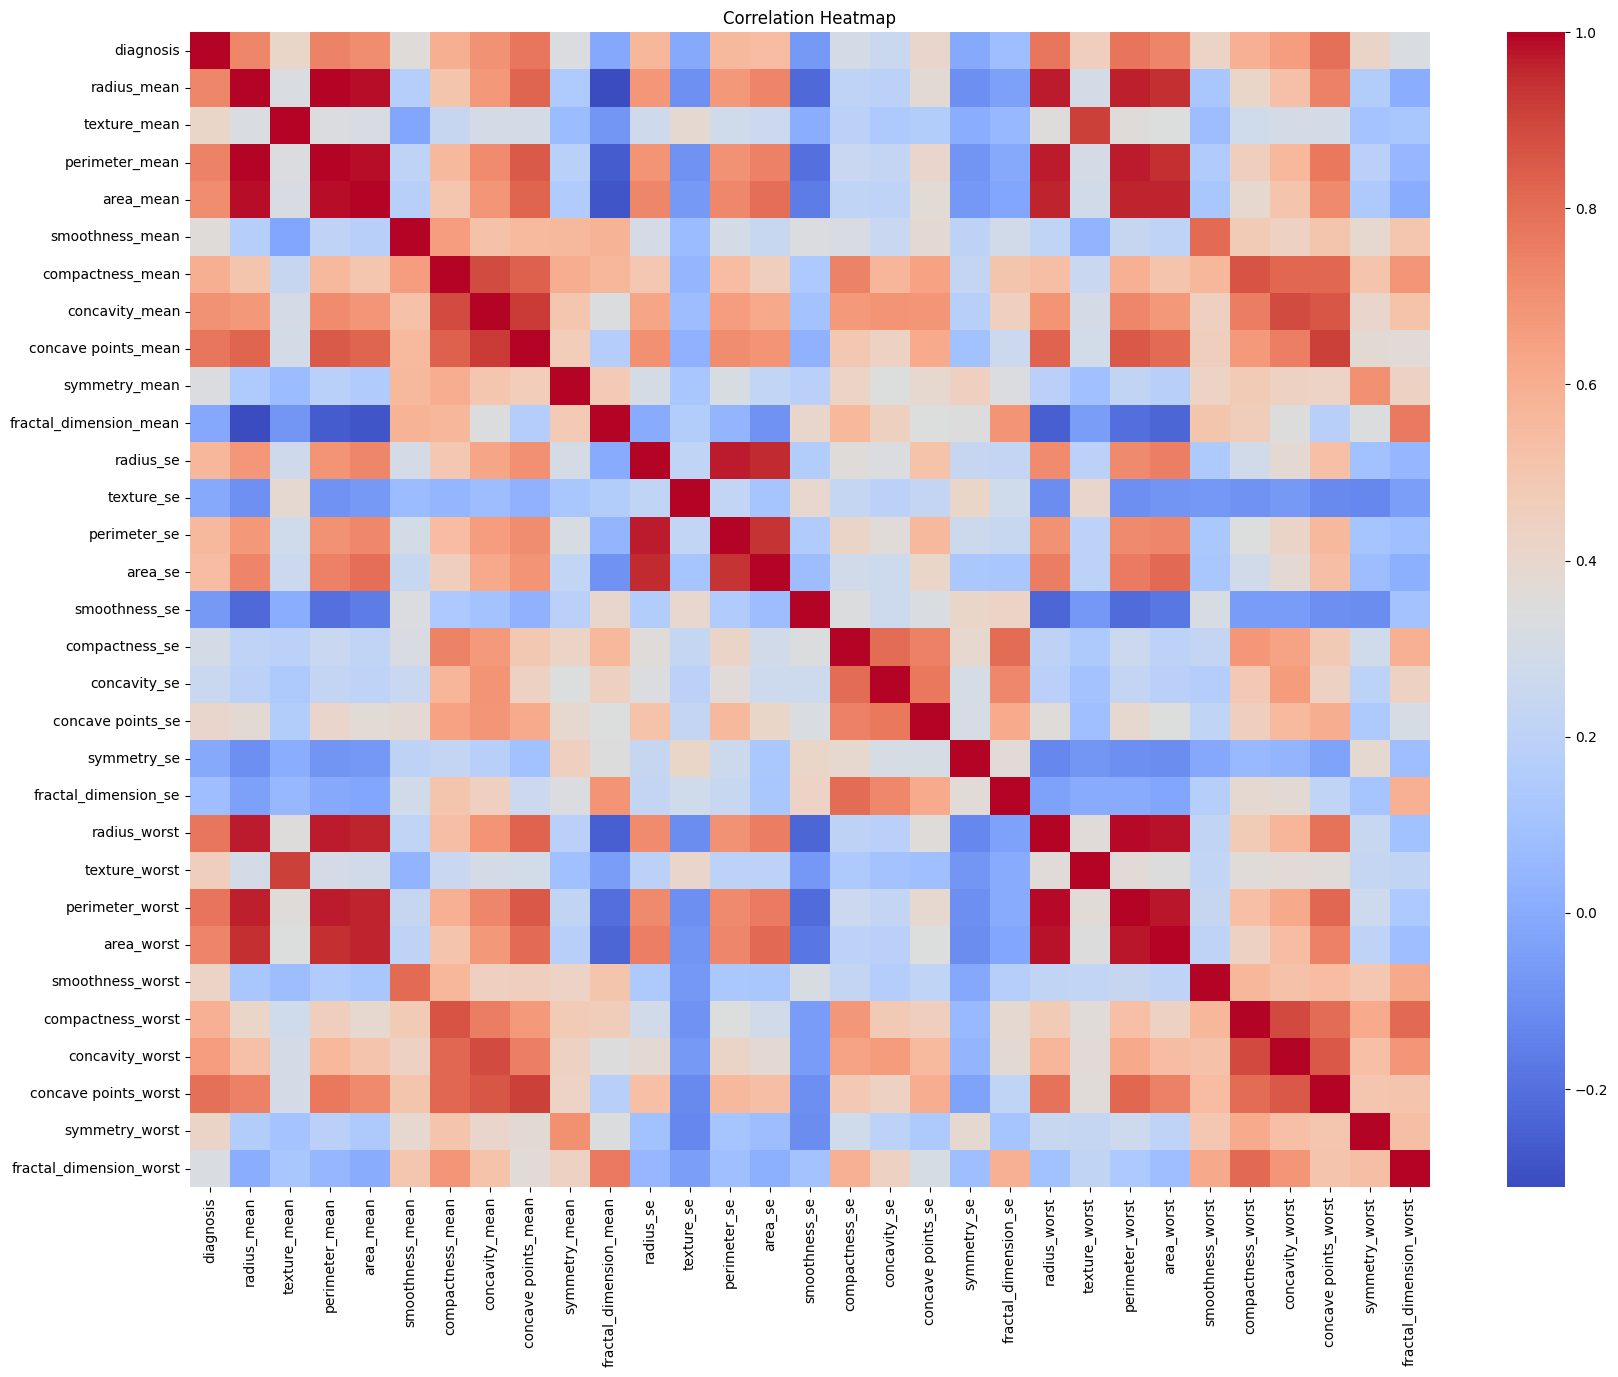

In [5]:
# ============================================
# Step 5: Exploratory Data Analysis
# ============================================

# Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x="diagnosis", data=data)

plt.title("Diagnosis Count")
plt.xticks([0,1], ["Benign", "Malignant"])
plt.show()

# Correlation Heatmap
plt.figure(figsize=(20,15))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [6]:
# ============================================
# Step 6: Split Features and Target
# ============================================

X = data.drop("diagnosis", axis=1)
y = data["diagnosis"]

In [7]:
# ============================================
# Step 7: Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


In [8]:
# ============================================
# Step 8: Build Random Forest Model
# ============================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
# ============================================
# Step 9: Prediction
# ============================================

y_pred = model.predict(X_test)


In [10]:
# ============================================
# Step 10: Model Evaluation
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 96.49122807017544

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



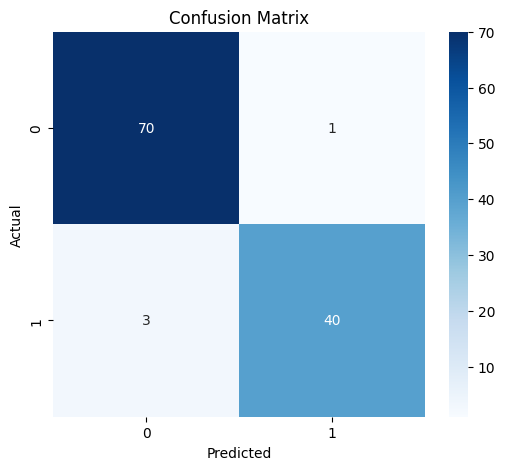

In [11]:
# ============================================
# Step 11: Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


Top 10 Important Features:
                 Feature  Importance
23            area_worst    0.153892
27  concave points_worst    0.144663
7    concave points_mean    0.106210
20          radius_worst    0.077987
6         concavity_mean    0.068001
22       perimeter_worst    0.067115
2         perimeter_mean    0.053270
0            radius_mean    0.048703
3              area_mean    0.047555
26       concavity_worst    0.031802


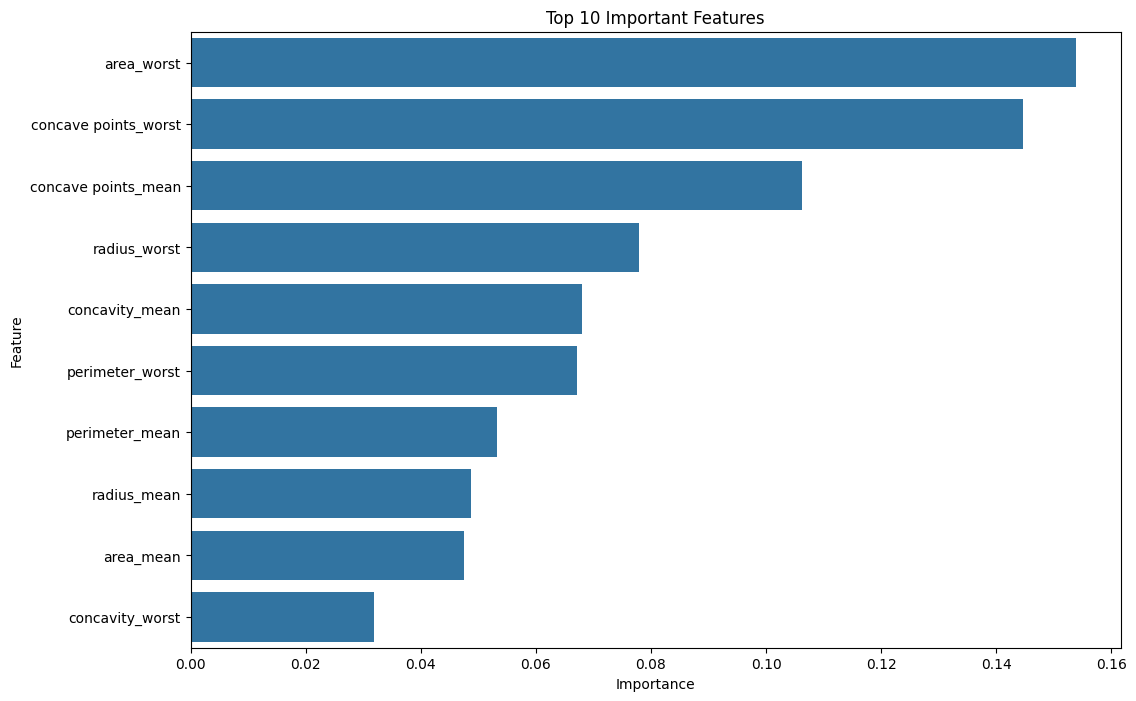

In [12]:
# ============================================
# Step 12: Feature Importance
# ============================================

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# Plot Feature Importance

plt.figure(figsize=(12,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()


In [13]:
# ============================================
# Step 13: Sample Prediction
# ============================================

sample = X.iloc[0].values.reshape(1, -1)

prediction = model.predict(sample)

if prediction[0] == 1:
    print("\nPrediction: Malignant Cancer")
else:
    print("\nPrediction: Benign Cancer")


Prediction: Malignant Cancer


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [14]:
# ============================================
# Step 14: Save Model (Optional)
# ============================================

import joblib

joblib.dump(model, "breast_cancer_model.pkl")

print("\nModel Saved Successfully!")


Model Saved Successfully!
